In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [31]:
df=pd.read_csv(
    "../data/processed/zomato_clustered.csv"
)

In [32]:
features = [

    "rate",

    "votes",

    "approx_cost",

    "popularity_score",

    "locality_avg_rating",

    "above_locality_avg",

    "rest_type_count",

    "cuisine_count",

    "log_votes"
]

In [33]:
X=df[features]

In [34]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [35]:
pca=PCA()

X_pca=pca.fit_transform(X_scaled)

In [36]:
explained_variance=pca.explained_variance_ratio_

In [37]:
cumulative_variance=np.cumsum(
    explained_variance
)
print(f'''  {explained_variance},
      

      {cumulative_variance}''')

  [3.30335302e-01 1.48097646e-01 1.15398626e-01 1.11036938e-01
 1.05551717e-01 1.01728948e-01 6.31202830e-02 2.45166475e-02
 2.13892618e-04],


      [0.3303353  0.47843295 0.59383157 0.70486851 0.81042023 0.91214918
 0.97526946 0.99978611 1.        ]


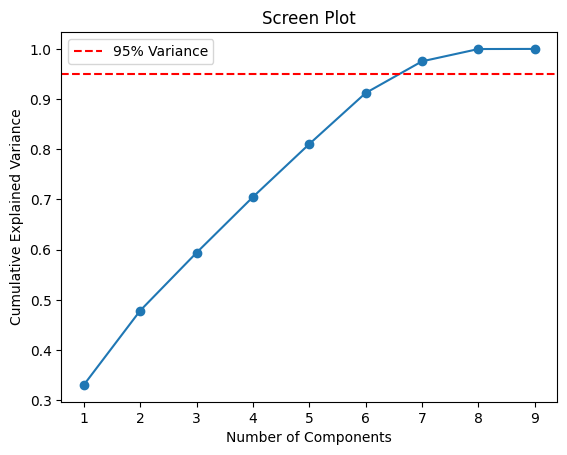

In [38]:
plt.Figure(figsize=(8,5))
plt.plot(
    range(1,len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)
plt.axhline(
    y=0.95,
    color="red",
    linestyle="--",
    label="95% Variance"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Screen Plot")
plt.legend()
plt.savefig(
    "../images/scree_plot.png",
    bbox_inches="tight"
)

plt.show()

In [39]:
n_components=7
pca=PCA(
    n_components=n_components
)

In [40]:
X_reduced=pca.fit_transform(X_scaled)

In [41]:
pca_variance_df=pd.DataFrame({
    "component":range(
        1,
        len(explained_variance)+1
    ),
    "Explained_Variance":explained_variance,
    "Cumulative_Variance":cumulative_variance
})

In [42]:
pca_variance_df.to_csv(
    "../reports/pca_variance.csv",
    index=False
)

In [43]:
pca_2d=PCA(n_components=2)

In [44]:
X_2d=pca_2d.fit_transform(X_scaled)

In [45]:
pca_df=pd.DataFrame({
    "PC1":X_2d[:,0],
    "PC2":X_2d[:,1],
    "cluster":df["cluster"]
})

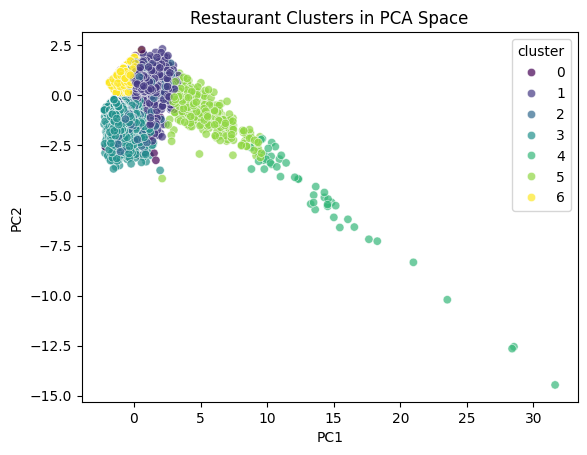

In [46]:
plt.Figure(figsize=(10,7))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="viridis",
    alpha=0.7
)
plt.title("Restaurant Clusters in PCA Space")
plt.savefig(
    "../images/pca_clusters.png",
    bbox_inches="tight"
)
plt.show()


In [48]:
loadings=pd.DataFrame(
    pca.components_.T,
    columns=[
        f"PC{i+1}" for i in range(n_components)
    ],
    index=features
)
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
rate,0.412441,0.523655,0.038457,0.022353,0.058182,0.043599,0.049393
votes,0.505473,-0.280674,-0.033589,-0.220751,-0.138645,-0.216000,-0.200712
approx_cost,0.007028,0.008514,0.685718,0.460934,-0.502476,-0.254324,0.004161
popularity_score,0.500982,-0.273769,-0.038902,-0.227826,-0.142779,-0.232738,-0.231700
locality_avg_rating,0.221746,0.056332,0.428951,0.191691,0.772161,-0.013249,-0.275721
above_locality_avg,0.261384,0.691694,-0.137487,-0.037716,-0.232911,0.063793,-0.026273
rest_type_count,0.102347,-0.026925,-0.523997,0.644851,0.137215,-0.510638,0.135694
cuisine_count,0.204892,-0.204588,-0.182707,0.480304,-0.169555,0.705465,-0.353847
log_votes,0.391674,-0.218613,0.121710,0.041372,0.080420,0.264421,0.826583


In [49]:
loadings.to_csv(
    "../reports/pca_loadings.csv"
)
pca_df.to_csv(
    "../reports/pca_2d_projection.csv",
    index=False
)

# Hour 3 Conclusions

1. PCA was applied to reduce dimensionality while preserving variance.
2. Scree plot analysis identified the optimal number of principal components.
3. Most variance was captured using a small number of components.
4. PCA visualization revealed meaningful restaurant cluster separation.
5. Viral and premium restaurant groups formed distinct regions in PCA space.
6. PCA improved interpretability of high-dimensional restaurant segmentation.